
# Growing Neural Cellular Automata with 3D Voxels

A compact Jupyter adaptation of **Cells2Pixels** voxel morphogenesis, with the implementation style kept close to Quentin Wach's GNCA tutorial.

This notebook keeps the pieces that matter for the repo's `growing_voxel` path:

- `GrowingVNCA`: 3D neural cellular automata with 16-ish channels, stochastic updates, 3D Sobel/Laplacian perception, and alpha-based living masks.
- 3D seed growth from a tiny center block.
- State pool training for persistence.
- A SIREN decoder that maps each upsampled NCA state + local voxel coordinates to RGBA.
- RGBA + occupancy voxel loss against a target volume.

Sources used while adapting:  
Cells2Pixels repo: https://github.com/TheDevilWillBeBee/Cells2Pixels  
GNCA tutorial: https://quentinwach.com/blog/2025/06/10/gnca.html


In [1]:
!pip install vtk --break-system-packages
!pip install trimesh
import math, random, struct, os
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
# Import this explicitly before torch.optim. Some Colab runtimes can leave the
# private helper submodule unattached after package installation/lazy imports.
import torch._utils
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import trange


def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(7)
if not hasattr(torch, '_utils'):
    raise RuntimeError(
        "PyTorch did not initialize correctly. Restart the Colab runtime, "
        "then run the notebook from the first cell."
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('device:', device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 21.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 60.9 MB/s eta 0:00:00
torch: 2.10.0+cu128
device: cuda


In [2]:
@dataclass
class CFG:
    target_inner_res: int = 128
    padding: int = 0
    scale_factor: int = 8
    channels: int = 48
    fc_dim: int = 256
    update_prob: float = 0.5
    seed_radius: int = 3
    pool_size: int = 256
    batch_size: int = 1
    virtual_batch_size: int = 1
    train_steps: int = 4000
    num_repetitions: int = 1
    step_range: tuple = (32, 64)
    inject_seed_interval: int = 2
    lr: float = 1e-3
    lr_decay_steps: tuple = (2000, 3000)
    lr_decay_gamma: float = 0.3
    overflow_weight: float = 100.0
    num_frequencies: int = 1
    precision: str = 'float16'

cfg = CFG()

# if device.type == 'cpu':
#     cfg.target_inner_res = 128
#     cfg.padding = 2
#     cfg.channels = 48
#     cfg.fc_dim =256
#     cfg.pool_size = 8
#     cfg.batch_size = 1
#     cfg.virtual_batch_size = 1
#     cfg.train_steps = 250
#     cfg.num_repetitions = 1
#     cfg.step_range = (32, 64)
#     cfg.inject_seed_interval = 2
#     cfg.overflow_weight = 100.0
#     cfg.precision = 'float16'

# ── Presets for tricky targets ──────────────────────────────────
# Uncomment ONE preset block below to override defaults.
# These help with targets that are thin, tall, or collapse during growth.

# ── Pine Tree / tall thin shapes ──
# cfg.seed_radius = 3
# cfg.step_range = (16, 48)
# cfg.overflow_weight = 40.0
# cfg.train_steps = 500
# cfg.inject_seed_interval = 1
# cfg.num_repetitions = 2
# cfg.living_threshold = 0.05



assert (cfg.target_inner_res + 2 * cfg.padding) % cfg.scale_factor == 0
cfg


CFG(target_inner_res=128, padding=0, scale_factor=8, channels=48, fc_dim=256, update_prob=0.5, seed_radius=3, pool_size=256, batch_size=1, virtual_batch_size=1, train_steps=4000, num_repetitions=1, step_range=(32, 64), inject_seed_interval=2, lr=0.001, lr_decay_steps=(2000, 3000), lr_decay_gamma=0.3, overflow_weight=100.0, num_frequencies=1, precision='float16')

## Target volume

Default target is procedural so the notebook runs anywhere. You can also train on:

- Cells2Pixels style: mesh `.obj` + solid texture `.vol`
- Dense voxel files: `.vox` from MagicaVoxel/MidVoxIO or `.npy` arrays

The training tensor is always dense RGBA `[1, D, H, W, 4]` in `zyx` order.


In [3]:
# Install gdown if needed
try:
    import gdown
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown"])
    import gdown

import os
import zipfile

def download_zip_and_extract(url, zip_path, output_dir, dataset_name):
    if os.path.exists(output_dir):
        print(f"{dataset_name} is already downloaded.")
        return
    
    os.makedirs(os.path.dirname(zip_path), exist_ok=True)
    gdown.download(url, zip_path, quiet=False)
    print(f"Unzipping the {dataset_name}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)
    os.remove(zip_path)
    print(f"Finished unzipping {dataset_name}!\n")

# Download meshes (contains Stanford Bunny)
download_zip_and_extract(
    url="https://drive.google.com/uc?id=136uliL3tcQinNXg3LXcJB4_Qf-HXg2A3",
    zip_path="data/meshes.zip",
    output_dir="data/meshes",
    dataset_name="Mesh dataset"
)

# Download solid textures (.vol files)
download_zip_and_extract(
    url="https://drive.google.com/uc?id=1Xa5RXDs_sEW7HihdMwG3duG-vViraY0f",
    zip_path="data/solid_textures.zip",
    output_dir="data/solid_textures",
    dataset_name="Solid Texture dataset (3D Volume Textures)"
)


Downloading...
From (original): https://drive.google.com/uc?id=136uliL3tcQinNXg3LXcJB4_Qf-HXg2A3
From (redirected): https://drive.google.com/uc?id=136uliL3tcQinNXg3LXcJB4_Qf-HXg2A3&confirm=t&uuid=ee39cd29-b1b2-4a66-923c-99393f4b655d
To: /content/data/meshes.zip
100%|██████████| 41.0M/41.0M [00:01<00:00, 33.9MB/s]


Unzipping the Mesh dataset...
Finished unzipping Mesh dataset!



Downloading...
From (original): https://drive.google.com/uc?id=1Xa5RXDs_sEW7HihdMwG3duG-vViraY0f
From (redirected): https://drive.google.com/uc?id=1Xa5RXDs_sEW7HihdMwG3duG-vViraY0f&confirm=t&uuid=3fb76406-3e47-424e-8b75-652c8fe96af0
To: /content/data/solid_textures.zip
100%|██████████| 92.2M/92.2M [00:02<00:00, 42.4MB/s]


Unzipping the Solid Texture dataset (3D Volume Textures)...
Finished unzipping Solid Texture dataset (3D Volume Textures)!



In [4]:
import numpy as np
from pathlib import Path
import torch
import torch.nn.functional as F
import struct

def _center_crop_or_pad(arr, shape):
    out = arr
    for axis, target in enumerate(shape):
        size = out.shape[axis]
        if size > target:
            start = (size - target) // 2
            idx = [slice(None)] * out.ndim
            idx[axis] = slice(start, start + target)
            out = out[tuple(idx)]
    pads = []
    for axis, target in enumerate(shape):
        size = out.shape[axis]
        before = max((target - size) // 2, 0)
        after = max(target - size - before, 0)
        pads.append((before, after))
    return np.pad(out, pads + [(0, 0)] * (out.ndim - len(pads)), mode='constant')


def normalize_rgba_array(arr, coord_order='zyx'):
    arr = np.asarray(arr)

    # Handle sparse list format [N, 6] -> [z, y, x, r, g, b]
    if arr.ndim == 2 and arr.shape[1] == 6:
        coords = arr[:, :3].astype(int)
        colors = arr[:, 3:].astype(np.float32)
        if colors.max() > 1.0:
            colors /= 255.0

        mins = coords.min(0)
        coords -= mins
        maxs = coords.max(0)

        dense = np.zeros((maxs[0]+1, maxs[1]+1, maxs[2]+1, 4), dtype=np.float32)
        for i in range(len(coords)):
            z, y, x = coords[i]
            dense[z, y, x, :3] = colors[i]
            dense[z, y, x, 3] = 1.0
        arr = dense

    if arr.ndim not in (3, 4):
        raise ValueError(f'Expected [D,H,W], [D,H,W,C], [X,Y,Z], or [X,Y,Z,C], got {arr.shape}')

    if coord_order.lower() == 'xyz':
        axes = (2, 1, 0) if arr.ndim == 3 else (2, 1, 0, 3)
        arr = np.transpose(arr, axes)
    elif coord_order.lower() != 'zyx':
        raise ValueError("coord_order must be 'zyx' or 'xyz'")

    arr = arr.astype(np.float32, copy=False)
    if arr.size and arr.max() > 1.0:
        arr = arr / 255.0

    if arr.ndim == 3:
        a = np.clip(arr[..., None], 0, 1)
        return np.concatenate([a, a, a, a], axis=-1).astype(np.float32)

    c = arr.shape[-1]
    if c == 1:
        a = np.clip(arr, 0, 1)
        return np.concatenate([a, a, a, a], axis=-1).astype(np.float32)
    if c == 3:
        rgb = np.clip(arr, 0, 1)
        a = (rgb.max(axis=-1, keepdims=True) > 0).astype(np.float32)
        return np.concatenate([rgb * a, a], axis=-1).astype(np.float32)
    if c >= 4:
        rgba = np.clip(arr[..., :4], 0, 1)
        rgba[..., :3] *= rgba[..., 3:4]
        return rgba.astype(np.float32)
    raise ValueError(f'Unsupported channel count: {c}')


def _load_midvoxio(auto_install=True):
    try:
        from midvoxio.voxio import vox_to_arr
        return vox_to_arr
    except Exception:
        if not auto_install:
            return None
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'git+https://github.com/midstreeeam/MidVoxIO.git'])
        from midvoxio.voxio import vox_to_arr
        return vox_to_arr


def read_magica_vox(path):
    path = Path(path)
    with open(path, 'rb') as f:
        data = f.read()
    if data[:4] != b'VOX ':
        raise ValueError('Not a MagicaVoxel .vox file')

    offset = 8
    size_xyz = None
    xyz_i = []
    palette = np.zeros((256, 4), dtype=np.uint8)
    palette[:, :3] = 255
    palette[:, 3] = 255

    while offset + 12 <= len(data):
        chunk_id = data[offset:offset+4]
        content_size = int.from_bytes(data[offset+4:offset+8], 'little')
        children_size = int.from_bytes(data[offset+8:offset+12], 'little')
        content = data[offset+12:offset+12+content_size]
        offset = offset + 12 + content_size

        if chunk_id == b'SIZE' and len(content) >= 12:
            size_xyz = tuple(int.from_bytes(content[i:i+4], 'little') for i in (0, 4, 8))
        elif chunk_id == b'XYZI' and len(content) >= 4:
            n = int.from_bytes(content[:4], 'little')
            pts = np.frombuffer(content[4:4+n*4], dtype=np.uint8).reshape(-1, 4)
            xyz_i.extend([tuple(map(int, p)) for p in pts])
        elif chunk_id == b'RGBA' and len(content) >= 1024:
            palette = np.frombuffer(content[:1024], dtype=np.uint8).reshape(256, 4).copy()
        offset += children_size

    if size_xyz is None:
        if xyz_i:
            pts = np.array(xyz_i, dtype=np.int32)
            size_xyz = tuple((pts[:, :3].max(axis=0) + 1).tolist())
        else:
            raise ValueError('No SIZE/XYZI chunks found in .vox')
    return xyz_i, palette, size_xyz


def load_voxel_file(path, coord_order='zyx', auto_install_midvoxio=True):
    """Load .npy or .vox to dense float32 [D,H,W,4]."""
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == '.npy':
        return normalize_rgba_array(np.load(path, allow_pickle=True), coord_order=coord_order)

    if suffix == '.vox':
        vox_to_arr = _load_midvoxio(auto_install=auto_install_midvoxio)
        if vox_to_arr is not None:
            try:
                arr = vox_to_arr(str(path), -1)
                return normalize_rgba_array(arr, coord_order='xyz')
            except Exception as exc:
                print(f"midvoxio failed; falling back to minimal parser. ({exc})")
        xyz_i, palette, size_xyz = read_magica_vox(path)
        xs, ys, zs = [int(v) for v in size_xyz]
        volume = np.zeros((zs, ys, xs, 4), dtype=np.float32)
        for x, y, z, ci in xyz_i:
            if 0 <= x < xs and 0 <= y < ys and 0 <= z < zs:
                color = palette[max(0, int(ci) - 1)].astype(np.float32) / 255.0
                color[3] = 1.0
                volume[z, y, x] = color
        return normalize_rgba_array(volume, coord_order='zyx')

    raise ValueError(f'Unsupported voxel file: {path.suffix}')


def _pad_rgba_volume(rgba, padding):
    if isinstance(padding, int):
        pads = [(padding, padding)] * 3
    else:
        pads = list(padding)
        if len(pads) == 3:
            pads = [(int(p), int(p)) for p in pads]
        elif len(pads) == 6:
            pads = [(int(pads[0]), int(pads[1])), (int(pads[2]), int(pads[3])), (int(pads[4]), int(pads[5]))]
        else:
            raise ValueError('padding must be an int, 3-tuple, or 6-tuple')
    return np.pad(rgba, pads + [(0, 0)], mode='constant')


def _pad_to_divisible(rgba, divisor):
    if divisor is None or int(divisor) <= 1:
        return rgba, (0, 0, 0)
    divisor = int(divisor)
    extras = tuple((divisor - (s % divisor)) % divisor for s in rgba.shape[:3])
    if not any(extras):
        return rgba, extras
    pads = [(e // 2, e - e // 2) for e in extras]
    return np.pad(rgba, pads + [(0, 0)], mode='constant'), extras


def dense_file_to_target(path, res=None, padding=8, coord_order='zyx', device=device, make_cubic=True, ensure_divisible_by=1):
    rgba = load_voxel_file(path, coord_order=coord_order)
    # Center the active voxels within the bounding box
    alpha = rgba[..., 3]
    nonzero = np.argwhere(alpha > 0.05)
    if len(nonzero) > 0:
        min_c = nonzero.min(axis=0)
        max_c = nonzero.max(axis=0)
        cropped = rgba[min_c[0]:max_c[0]+1, min_c[1]:max_c[1]+1, min_c[2]:max_c[2]+1]
        rgba = _center_crop_or_pad(cropped, rgba.shape[:3])
    original_shape = tuple(int(v) for v in rgba.shape[:3])

    if res is not None:
        res = int(res)
        rgba = _center_crop_or_pad(rgba, (res, res, res))
    elif make_cubic:
        cube_size = int(max(rgba.shape[:3]))
        rgba = _center_crop_or_pad(rgba, (cube_size, cube_size, cube_size))

    pre_pad_shape = tuple(int(v) for v in rgba.shape[:3])
    rgba = _pad_rgba_volume(rgba, int(padding))
    rgba, extra = _pad_to_divisible(rgba, ensure_divisible_by)
    final_shape = tuple(int(v) for v in rgba.shape[:3])

    print('loaded dense target:', path)
    print('  original:', original_shape)
    print('  before padding:', pre_pad_shape)
    print('  padding each side:', int(padding))
    if any(extra):
        print('  extra empty padding for scale divisibility:', extra)
    print('  final decoded target:', final_shape)

    return torch.tensor(rgba[None], dtype=torch.float32, device=device)


def read_cells2pixels_vol(filepath):
    with open(filepath, 'rb') as f:
        header = f.read(4096)
        magic, version, tex_name, wrap, vol_size, num_channels, bytes_per_channel = struct.Struct('4si256s?iii').unpack_from(header)
        if magic != b'VOLU' or version != 4 or bytes_per_channel != 1:
            raise ValueError('Unsupported .vol file')
        n = vol_size * vol_size * vol_size * num_channels
        data = np.frombuffer(f.read(n), dtype=np.uint8)
    return data.reshape((vol_size, vol_size, vol_size, num_channels))


def load_mesh_solid_texture_target(mesh_path, vol_path, res=32, padding=8, device=device, ensure_divisible_by=1):
    import trimesh
    mesh = trimesh.load(mesh_path, force='mesh')
    mesh.apply_translation(-mesh.centroid)
    mesh.apply_scale(1.0 / max(mesh.extents))
    occupancy = mesh.voxelized(pitch=1.0 / (res - 1)).fill().matrix.astype(np.float32)
    occupancy = _center_crop_or_pad(occupancy[..., None], (res, res, res))[..., 0]

    solid = read_cells2pixels_vol(vol_path).astype(np.float32) / 255.0
    reps = [res // solid.shape[i] + int(res % solid.shape[i] != 0) for i in range(3)]
    color = np.tile(solid, (*reps, 1))[:res, :res, :res, :3]
    rgba = np.concatenate([color * occupancy[..., None], occupancy[..., None]], axis=-1)
    rgba = np.pad(rgba, ((padding, padding), (padding, padding), (padding, padding), (0, 0)))
    rgba, extra = _pad_to_divisible(rgba, ensure_divisible_by)
    return torch.tensor(rgba[None], dtype=torch.float32, device=device)


def load_obj_target(mesh_path, res=64, padding=8, color=[0.5, 0.5, 0.5], device=device, ensure_divisible_by=1):
    import trimesh
    mesh = trimesh.load(mesh_path, force='mesh')
    mesh.apply_translation(-mesh.centroid)
    mesh.apply_scale(1.0 / max(mesh.extents))
    voxel_grid = mesh.voxelized(pitch=1.0 / (res - 1))
    occupancy = voxel_grid.fill().matrix.astype(np.float32)
    occupancy = _center_crop_or_pad(occupancy[..., None], (res, res, res))[..., 0]
    rgb = np.zeros((*occupancy.shape, 3), dtype=np.float32)
    rgb[occupancy > 0.5] = color
    rgba = np.concatenate([rgb, occupancy[..., None]], axis=-1)
    rgba = _pad_rgba_volume(rgba, int(padding))
    rgba, extra = _pad_to_divisible(rgba, ensure_divisible_by)
    return torch.tensor(rgba[None], dtype=torch.float32, device=device)


In [5]:

def depthwise_conv3d(x, filters, padding='circular'):
    b, c, d, h, w = x.shape
    y = x.reshape(b * c, 1, d, h, w)
    y = F.pad(y, (1, 1, 1, 1, 1, 1), mode=padding)
    y = F.conv3d(y, filters[:, None])
    return y.reshape(b, c * filters.shape[0], d, h, w)


class VNCA3D(nn.Module):
    def __init__(self, channels=16, fc_dim=128, update_prob=0.5, padding='circular', precision=torch.float32):
        super().__init__()
        self.channels = channels
        self.update_prob = update_prob
        self.padding = padding
        self.perception_kernels = 5
        self.precision = precision
        self.w1 = nn.Conv3d(channels * self.perception_kernels, fc_dim, 1)
        self.w2 = nn.Conv3d(fc_dim, channels, 1, bias=False)
        nn.init.xavier_normal_(self.w1.weight, gain=0.1)
        nn.init.xavier_normal_(self.w2.weight, gain=0.1)
        self.register_buffer('filters', self._filters(precision))

    @staticmethod
    def _filters(precision):
        d1 = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], dtype=precision)
        d2 = torch.tensor([[-2., 0., 2.], [-4., 0., 4.], [-2., 0., 2.]], dtype=precision)
        sobel_z = torch.stack([d1, d2, d1]) / 2.0
        sobel_y = sobel_z.permute(0, 2, 1)
        sobel_x = sobel_z.permute(2, 1, 0)
        lap1 = torch.tensor([[2., 3., 2.], [3., 6., 3.], [2., 3., 2.]], dtype=precision)
        lap2 = torch.tensor([[3., 6., 3.], [6., -88., 6.], [3., 6., 3.]], dtype=precision)
        lap = torch.stack([lap1, lap2, lap1]) / 8.0
        ident = torch.zeros(3, 3, 3, dtype=precision)
        ident[1, 1, 1] = 1.0
        return torch.stack([ident, sobel_x, sobel_y, sobel_z, lap])

    def forward(self, s):
        z = depthwise_conv3d(s, self.filters.to(dtype=s.dtype), self.padding)
        ds = self.w2(F.relu(self.w1(z)))
        if self.update_prob < 1.0:
            mask = (torch.rand(s.shape[0], 1, s.shape[2], s.shape[3], s.shape[4], device=s.device, dtype=self.precision) < self.update_prob).to(s.dtype)
            ds = ds * mask
        return s + ds, z

    def seed(self, n, d, h, w):
        return torch.zeros(n, self.channels, d, h, w, device=next(self.parameters()).device, dtype=self.precision)


class GrowingVNCA3D(VNCA3D):
    def __init__(self, seed_radius=1, **kwargs):
        super().__init__(**kwargs)
        self.seed_radius = seed_radius

    @staticmethod
    def living_mask(s):
        return F.max_pool3d(s[:, 3:4], 3, stride=1, padding=1) > 0.1

    def forward(self, s):
        pre = self.living_mask(s)
        s, z = super().forward(s)
        post = self.living_mask(s)
        return s * (pre & post).to(self.precision), z

    def seed(self, n, d, h, w):
        s = super().seed(n, d, h, w)
        r = self.seed_radius - 1
        c = (d // 2, h // 2, w // 2)
        s[:, 3:, c[0]-r:c[0]+r+1, c[1]-r:c[1]+r+1, c[2]-r:c[2]+r+1] = 1.0
        return s


In [6]:
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=10.0, activation='sin', fx='linear'):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.fx = fx
        self.linear = nn.Linear(in_features, out_features)
        self.activation = torch.sin if activation == 'sin' else getattr(F, activation)
        self.init_weights(in_features)

    def init_weights(self, in_features):
        with torch.no_grad():
            bound = 1 / in_features if self.is_first else math.sqrt(6 / in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        x = self.linear(x)
        if self.fx == 'finer':
            x = x * (1.0 + torch.abs(x))
        elif self.fx == 'sinh':
            x = torch.sinh(2.0 * x)
        return self.activation(self.omega_0 * x)


class SirenDecoder(nn.Module):
    def __init__(self, in_features, coord_dim=3, hidden_features=32, hidden_layers=2, out_features=4,
                 num_frequencies=1, first_omega_0=10.0, hidden_omega_0=10.0, fx='linear', activation='sin'):
        super().__init__()
        self.num_frequencies = num_frequencies
        enc_coord_dim = coord_dim * max(1, 2 * num_frequencies)
        layers = [SineLayer(in_features + enc_coord_dim, hidden_features, is_first=True,
                            omega_0=first_omega_0, activation=activation, fx=fx)]
        for _ in range(hidden_layers):
            layers.append(SineLayer(hidden_features, hidden_features, omega_0=hidden_omega_0,
                                    activation=activation, fx=fx))
        final = nn.Linear(hidden_features, out_features)
        with torch.no_grad():
            final.weight.uniform_(-math.sqrt(6 / hidden_features) / hidden_omega_0,
                                  math.sqrt(6 / hidden_features) / hidden_omega_0)
        layers.append(final)
        self.net = nn.Sequential(*layers)

    def encode_coords(self, coords):
        if self.num_frequencies <= 0:
            return coords
        freqs = torch.arange(1, self.num_frequencies + 1, device=coords.device, dtype=coords.dtype)
        a = coords[..., None, :] * math.pi * freqs[:, None]
        return torch.cat([torch.sin(a).flatten(-2), torch.cos(a).flatten(-2)], dim=-1)

    def forward(self, cell_states, coords):
        x = torch.cat([self.encode_coords(coords), cell_states], dim=-1)
        return self.net(x)

In [7]:
from contextlib import nullcontext


def precision_from_cfg(cfg):
    if device.type == 'cuda' and getattr(cfg, 'precision', 'float32') == 'float16':
        return torch.float16
    return torch.float32


def autocast_context(run_device, precision):
    enabled = run_device.type == 'cuda' and precision == torch.float16
    return torch.autocast(device_type=run_device.type, dtype=precision) if enabled else nullcontext()


def make_grad_scaler(run_device, precision):
    enabled = run_device.type == 'cuda' and precision == torch.float16
    return torch.amp.GradScaler(run_device.type, enabled=enabled)


def optimizer_scheduler_step(opt, sched, scaler, precision):
    if precision == torch.float16:
        scale_before = scaler.get_scale()
        scaler.step(opt)
        scaler.update()
        stepped = scaler.get_scale() >= scale_before
    else:
        opt.step()
        stepped = True
    if stepped:
        sched.step()


def local_subcell_coords(scale_factor, device, dtype=torch.float32):
    t = (torch.arange(scale_factor, device=device, dtype=dtype) / scale_factor - 0.5 + 0.5 / scale_factor) * 2.0
    z, y, x = torch.meshgrid(t, t, t, indexing='ij')
    return torch.stack([z, y, x], dim=-1)


def decode_voxel(model, siren, state, z, grid_size, scale_factor, precision):
    x_render = state.float()
    x_pad = F.pad(x_render, (1, 1, 1, 1, 1, 1), mode='circular')
    x_up = F.interpolate(x_pad, scale_factor=scale_factor, mode='trilinear', align_corners=False)
    x_up = x_up[:, :, scale_factor:-scale_factor, scale_factor:-scale_factor, scale_factor:-scale_factor]
    b = x_up.shape[0]
    coords = local_subcell_coords(scale_factor, x_up.device, torch.float32)[None].repeat(b, *grid_size, 1)
    cells = x_up.permute(0, 2, 3, 4, 1)
    living = model.living_mask(x_up).float().permute(0, 2, 3, 4, 1)
    with autocast_context(x_up.device, precision):
        generated = siren(cells, coords)
    return (generated * living).float(), x_up.float()


def psnr(x, y):
    mse = ((x.clamp(0, 1) - y.clamp(0, 1)) ** 2).mean()
    return -10.0 * torch.log10(mse + 1e-8)


def voxel_morphogenesis_loss(generated, target, state, upsampled_state, overflow_weight=100.0):
    alpha_state = upsampled_state[:, 3:4].permute(0, 2, 3, 4, 1) * 2.0
    rgba_l2 = ((generated - target) ** 2).mean()
    rgba_l1 = (generated - target).abs().mean()
    occ_l2 = ((alpha_state - target[..., 3:4]) ** 2).mean()
    occ_l1 = (alpha_state - target[..., 3:4]).abs().mean()
    overflow_state = state.float()
    overflow = (overflow_state - overflow_state.clamp(-1.0, 1.0)).abs().mean()
    loss = rgba_l2 + rgba_l1 + occ_l2 + occ_l1 + overflow_weight * overflow
    return loss, {
        'loss': float(loss.detach()),
        'rgba_l2': float(rgba_l2.detach()),
        'rgba_l1': float(rgba_l1.detach()),
        'occ_l2': float(occ_l2.detach()),
        'occ_l1': float(occ_l1.detach()),
        'overflow': float(overflow.detach()),
        'psnr': float(psnr(generated, target).detach()),
        'alpha_max': float(alpha_state.detach().max()),
    }


def normalize_model_grads(model):
    for p in model.parameters():
        if p.grad is not None:
            p.grad /= p.grad.norm() + 1e-8

In [8]:
def rgba_on_white(x):
    x = x.detach().float().cpu().numpy()
    rgb = np.clip(x[..., :3], 0, 1)
    a = np.clip(x[..., 3:4], 0, 1)
    return np.clip(rgb * a + (1.0 - a), 0, 1)


def show_slices(generated, target, title='generated vs target'):
    gen = generated[0]
    tgt = target[0]
    d, h, w = gen.shape[:3]
    cuts = [(d // 2, 'YZ'), (h // 2, 'XZ'), (w // 2, 'XY')]
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    for j, (idx, name) in enumerate(cuts):
        gs = gen[idx] if j == 0 else gen[:, idx] if j == 1 else gen[:, :, idx]
        ts = tgt[idx] if j == 0 else tgt[:, idx] if j == 1 else tgt[:, :, idx]
        axes[0, j].imshow(rgba_on_white(gs)); axes[0, j].set_title(f'gen {name}')
        axes[1, j].imshow(rgba_on_white(ts)); axes[1, j].set_title(f'target {name}')
        axes[0, j].axis('off'); axes[1, j].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_history(history):
    if not history:
        return
    steps = [h['step'] for h in history]
    plt.figure(figsize=(6, 3))
    plt.plot(steps, [h['loss'] for h in history], label='loss')
    plt.plot(steps, [h['occ_l2'] for h in history], label='occupancy L2')
    plt.yscale('log')
    plt.legend()
    plt.xlabel('step')
    plt.show()


def voxel_scatter(rgba, threshold=0.5, max_points=12000):
    v = rgba[0].detach().float().cpu()
    alpha = v[..., 3].clamp(0, 1)
    pts = torch.nonzero(alpha > threshold)
    if len(pts) == 0:
        print('no occupied voxels above threshold')
        print('alpha min/max/mean:', float(alpha.min()), float(alpha.max()), float(alpha.mean()))
        return
    if len(pts) > max_points:
        pts = pts[torch.randperm(len(pts))[:max_points]]
    colors = v[pts[:, 0], pts[:, 1], pts[:, 2], :3].clamp(0, 1).numpy()
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pts[:, 2], pts[:, 1], pts[:, 0], s=2, c=colors)
    ax.set_axis_off()
    plt.show()

In [9]:
def make_models(cfg):
    precision = precision_from_cfg(cfg)
    model = GrowingVNCA3D(
        channels=cfg.channels,
        fc_dim=cfg.fc_dim,
        update_prob=cfg.update_prob,
        seed_radius=cfg.seed_radius,
        precision=precision,
    ).to(device)
    siren = SirenDecoder(
        cfg.channels,
        hidden_features=32,
        hidden_layers=2,
        out_features=4,
        num_frequencies=cfg.num_frequencies,
        first_omega_0=10.0,
        hidden_omega_0=10.0,
    ).to(device)
    return model, siren, precision


def prune_dead_pool(pool, model, grid_size, threshold=0.01):
    """Replace collapsed (all-dead) pool entries with fresh seeds."""
    with torch.no_grad():
        alive_per_sample = pool[:, 3:4].abs().amax(dim=(1, 2, 3, 4))  # [pool_size]
        dead_mask = alive_per_sample < threshold
        n_dead = int(dead_mask.sum().item())
        if n_dead > 0:
            fresh = model.seed(n_dead, *grid_size)
            pool[dead_mask] = fresh
        return n_dead


def train_voxel_gnca(target, cfg):
    model, siren, precision = make_models(cfg)
    grid_size = tuple(s // cfg.scale_factor for s in target.shape[1:4])
    history = []
    accumulation_steps = max(1, math.ceil(cfg.virtual_batch_size / cfg.batch_size))

    for rep in range(cfg.num_repetitions):
        pool = model.seed(cfg.pool_size, *grid_size)
        inject_interval = cfg.inject_seed_interval * (2 ** rep)
        opt = torch.optim.Adam(list(model.parameters()) + list(siren.parameters()), lr=cfg.lr)
        sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=list(cfg.lr_decay_steps), gamma=cfg.lr_decay_gamma)
        scaler = make_grad_scaler(device, precision)
        opt.zero_grad(set_to_none=True)
        acc = 0

        pbar = trange(cfg.train_steps * accumulation_steps, desc=f'Repetition {rep + 1}/{cfg.num_repetitions}')
        for epoch in pbar:
            log_step = (epoch + rep * cfg.train_steps * accumulation_steps) // accumulation_steps

            # ── Pool pruning: replace any fully-collapsed entries with fresh seeds ──
            if epoch % (accumulation_steps * 10) == 0:
                n_dead = prune_dead_pool(pool, model, grid_size)

            idx = torch.randperm(cfg.pool_size, device=device)[:cfg.batch_size]
            x = pool[idx].clone()
            if log_step % inject_interval == 0 and acc == 0:
                x[:1] = model.seed(1, *grid_size)

            n_steps = random.randrange(*cfg.step_range)
            z = None
            with autocast_context(device, precision):
                for _ in range(n_steps):
                    x, z = model(x)

            with torch.no_grad():
                pool[idx] = x.detach()

            generated, x_up = decode_voxel(model, siren, x, z, grid_size, cfg.scale_factor, precision)
            loss, logs = voxel_morphogenesis_loss(generated, target, x, x_up, cfg.overflow_weight)
            pbar.set_postfix(loss=loss.item())
            loss_to_backprop = loss / accumulation_steps
            if precision == torch.float16:
                scaler.scale(loss_to_backprop).backward()
            else:
                loss_to_backprop.backward()
            acc += 1

            if acc == accumulation_steps:
                if precision == torch.float16:
                    scaler.unscale_(opt)
                normalize_model_grads(model)
                torch.nn.utils.clip_grad_norm_(siren.parameters(), 1.0)
                optimizer_scheduler_step(opt, sched, scaler, precision)
                opt.zero_grad(set_to_none=True)
                acc = 0

            if log_step % 50 == 0 or log_step == cfg.train_steps * cfg.num_repetitions - 1:
                logs['step'] = log_step
                logs['rep'] = rep + 1
                logs['rollout_steps'] = n_steps
                logs['pool_dead'] = n_dead if 'n_dead' in dir() else 0
                history.append(logs)

        with torch.no_grad():
            preview = model.seed(1, *grid_size)
            preview_z = None
            with autocast_context(device, precision):
                for _ in range(max(cfg.step_range) * 2):
                    preview, preview_z = model(preview)
            preview_generated, _ = decode_voxel(model, siren, preview, preview_z, grid_size, cfg.scale_factor, precision)
        show_slices(preview_generated, target, title=f'after repetition {rep + 1}/{cfg.num_repetitions}')
    return model, siren, history


@torch.no_grad()
def rollout(model, siren, cfg, steps=96):
    precision = getattr(model, 'precision', precision_from_cfg(cfg))
    grid_size = tuple(s // cfg.scale_factor for s in target.shape[1:4])
    x = model.seed(1, *grid_size)
    z = None
    with autocast_context(device, precision):
        for _ in range(steps):
            x, z = model(x)
    generated, x_up = decode_voxel(model, siren, x, z, grid_size, cfg.scale_factor, precision)
    return generated, x



## Choose target path before training

Dense `.vox` / `.npy` targets now preserve their original voxel resolution by default. Set `DENSE_RESIZE_TO` only for a small demo.

In [10]:
import numpy as np
from pathlib import Path

# # Target selection (Stanford Bunny)
!wget -O Furnace.vox "https://voxbox.store/api/model/download?id=ei6SEQJPSs"
# Target selection
USE_DENSE_TARGET = True
DENSE_TARGET_PATH = '/content/frog.npy'

# OBJ Mesh + VOL Solid Texture target loading option:
# MESH_PATH = './data/meshes/fish/fish.obj'
# VOL_PATH = './data/solid_textures/tomatoes.vol'
# target = load_mesh_solid_texture_target(
#     MESH_PATH,
#     VOL_PATH,
#     res=128,
#     padding=8,
#     ensure_divisible_by=cfg.scale_factor
# )
NPY_COORD_ORDER = 'zyx'

# None = preserve original size. Set an int like 32 only for a quick demo.
DENSE_RESIZE_TO = None
DENSE_PADDING = 4
DENSE_MAKE_CUBIC = True

# Load the target
target = dense_file_to_target(
    DENSE_TARGET_PATH,
    res=DENSE_RESIZE_TO,
    padding=DENSE_PADDING,
    coord_order=NPY_COORD_ORDER,
    make_cubic=DENSE_MAKE_CUBIC,
    ensure_divisible_by=cfg.scale_factor,
)

target_path_for_export = "Boston Tea Pot.npy"

spatial = tuple(int(s) for s in target.shape[1:4])

if any(s % cfg.scale_factor != 0 for s in spatial):
    raise ValueError(f'target shape {spatial} must be divisible by scale_factor={cfg.scale_factor}')

print('target_path_for_export:', target_path_for_export)
print('target:', tuple(target.shape), 'NCA grid:', tuple(s // cfg.scale_factor for s in spatial))


--2026-07-15 22:13:39--  https://voxbox.store/api/model/download?id=ei6SEQJPSs
Resolving voxbox.store (voxbox.store)... 5.161.231.181, 2a01:4ff:f0:8ec9::1
Connecting to voxbox.store (voxbox.store)|5.161.231.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6504 (6.4K) [application/x-authorware-bin]
Saving to: ‘Furnace.vox’

Furnace.vox         100%[===================>]   6.35K  --.-KB/s    in 0s      

2026-07-15 22:13:41 (955 MB/s) - ‘Furnace.vox’ saved [6504/6504]

loaded dense target: /content/frog.npy
  original: (44, 256, 256)
  before padding: (256, 256, 256)
  padding each side: 4
  final decoded target: (264, 264, 264)
target_path_for_export: Boston Tea Pot.npy
target: (1, 264, 264, 264, 4) NCA grid: (33, 33, 33)


full: (264, 264, 264, 4)
coarse: (33, 33, 33, 4)
coarse occupancy fraction: 0.025041046
coarse occupied voxels: 1202


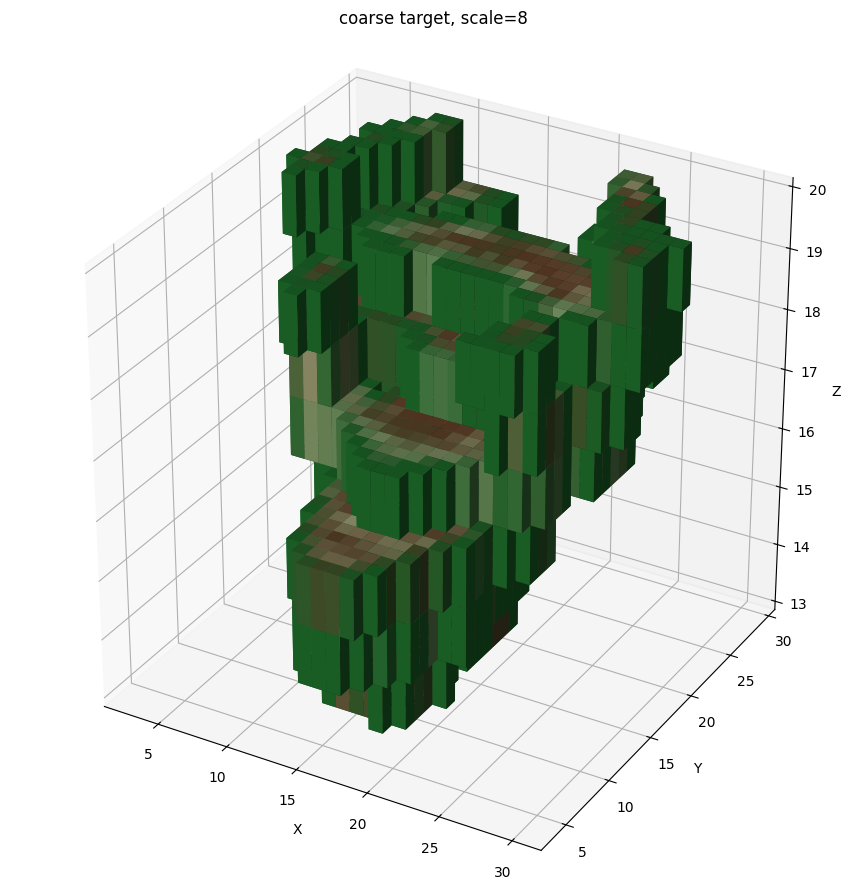

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

def to_np_rgba(v):
    if isinstance(v, torch.Tensor):
        v = v.detach().cpu().numpy()
    if v.ndim == 5:  # [B,D,H,W,4]
        v = v[0]
    return v

def make_coarse_rgba(vol, scale_factor=2):
    """
    vol: [D,H,W,4] in Z,Y,X,RGBA
    returns coarse [D/s,H/s,W/s,4]
    """
    D, H, W, C = vol.shape
    s = scale_factor

    D2 = (D // s) * s
    H2 = (H // s) * s
    W2 = (W // s) * s
    vol = vol[:D2, :H2, :W2]

    rgba = torch.from_numpy(vol).float().permute(3, 0, 1, 2).unsqueeze(0)  # [1,4,D,H,W]

    alpha = rgba[:, 3:4]
    coarse_alpha = F.max_pool3d(alpha, kernel_size=s, stride=s)

    rgb = rgba[:, :3] * alpha
    coarse_rgb_sum = F.avg_pool3d(rgb, kernel_size=s, stride=s) * (s ** 3)
    coarse_count = F.avg_pool3d(alpha, kernel_size=s, stride=s) * (s ** 3)
    coarse_rgb = coarse_rgb_sum / coarse_count.clamp_min(1e-6)

    coarse = torch.cat([coarse_rgb, coarse_alpha], dim=1)
    coarse = coarse[0].permute(1, 2, 3, 0).numpy()  # [D,H,W,4]
    return coarse

def show_voxels_matplotlib(vol, threshold=0.5, title="voxel"):
    """
    vol: [D,H,W,4] in Z,Y,X,RGBA
    """
    alpha = vol[..., 3]
    filled = alpha > threshold

    colors = vol.copy()
    colors[..., 3] = np.where(filled, 1.0, 0.0)

    # matplotlib wants X,Y,Z
    filled_xyz = np.transpose(filled, (2, 1, 0))
    colors_xyz = np.transpose(colors, (2, 1, 0, 3))

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(projection="3d")
    ax.voxels(filled_xyz, facecolors=colors_xyz, edgecolor=None)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect(filled_xyz.shape)
    plt.tight_layout()
    plt.show()

vol = to_np_rgba(target)
coarse = make_coarse_rgba(vol, scale_factor=cfg.scale_factor)

print("full:", vol.shape)
print("coarse:", coarse.shape)
print("coarse occupancy fraction:", coarse[..., 3].mean())
print("coarse occupied voxels:", int((coarse[..., 3] > 0.5).sum()))

show_voxels_matplotlib(coarse, threshold=0.5, title=f"coarse target, scale={cfg.scale_factor}")

## Train

This version follows the official `growing-voxel.yaml` recipe more closely, with extra 3D capacity: `GrowingVNCA`, `channels=32`, `fc_dim=256`, `seed_radius=3`, `scale_factor=2`, `step_range=(32,64)`, pool training, seed reinjection, Adam + LR decay, NCA gradient normalization, and voxel L2/L1 + occupancy L2/L1 + overflow loss.

For a fast smoke test, lower `cfg.train_steps` and `cfg.num_repetitions`. For quality, keep the official-style settings and run on GPU.

Repetition 1/1:   0%|          | 0/4000 [00:00<?, ?it/s]

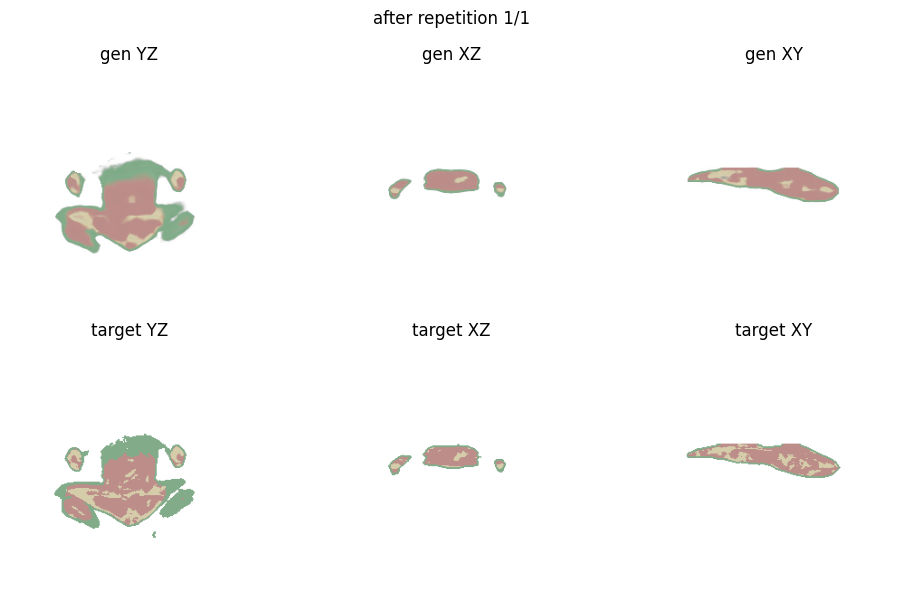

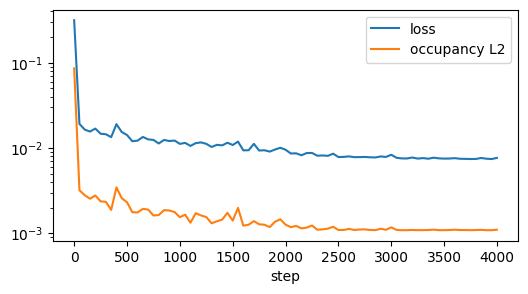

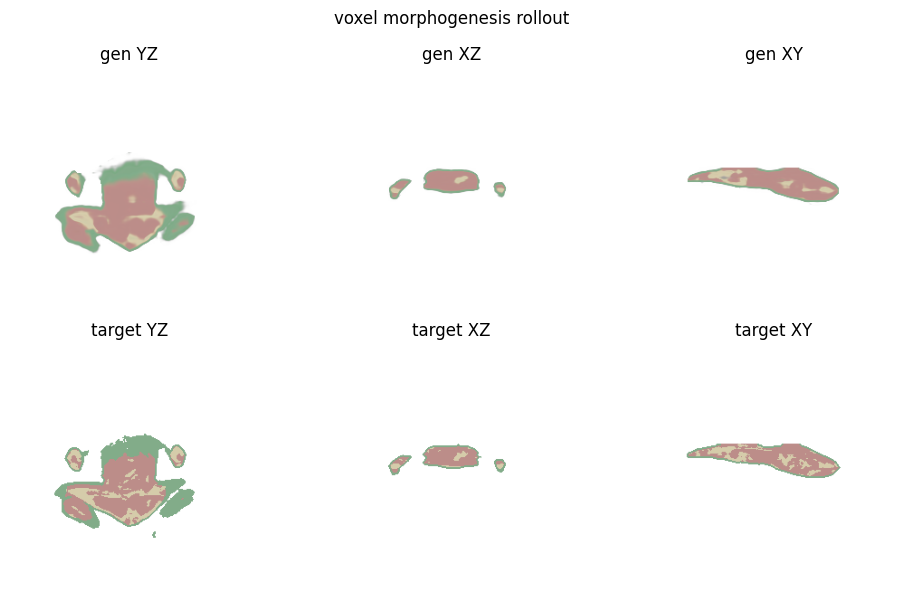

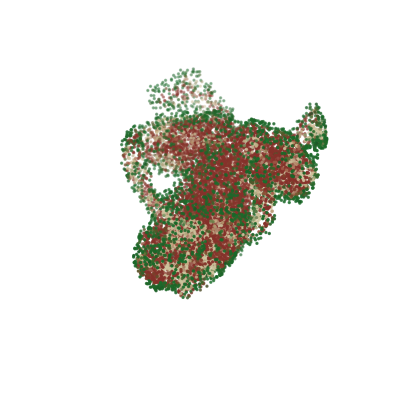

In [12]:

model, siren, history = train_voxel_gnca(target, cfg)
plot_history(history)

generated, final_state = rollout(model, siren, cfg, steps=max(cfg.step_range) * 2)
show_slices(generated, target, title='voxel morphogenesis rollout')
voxel_scatter(generated, threshold=0.45)



## Optional persistence / damage probe

This is not a separate damage-training loop; it just checks whether the pool-trained attractor survives a cut. If you want stronger regeneration, add random damage to a subset of pool states before the rollout in the training loop.


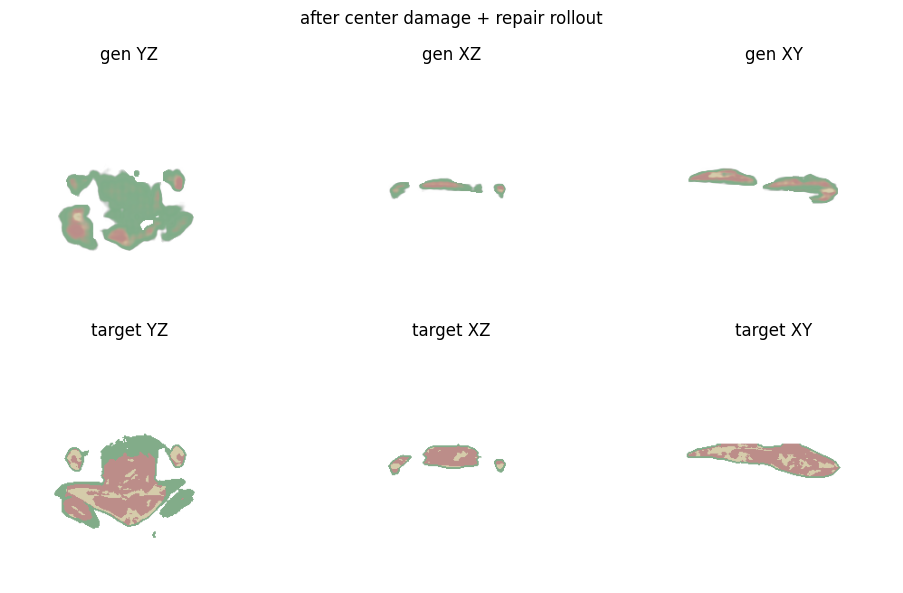

In [13]:

@torch.no_grad()
def damage_state_center(state, frac=0.35):
    x = state.clone()
    _, _, d, h, w = x.shape
    rd, rh, rw = int(d * frac / 2), int(h * frac / 2), int(w * frac / 2)
    cd, ch, cw = d // 2, h // 2, w // 2
    x[:, :, cd-rd:cd+rd, ch-rh:ch+rh, cw-rw:cw+rw] = 0
    return x

@torch.no_grad()
def repair_rollout(model, siren, state, cfg, repair_steps=64):
    precision = getattr(model, 'precision', precision_from_cfg(cfg))
    grid_size = tuple(s // cfg.scale_factor for s in target.shape[1:4])
    x = damage_state_center(state)
    z = None
    with autocast_context(device, precision):
        for _ in range(repair_steps):
            x, z = model(x)
    return decode_voxel(model, siren, x, z, grid_size, cfg.scale_factor, precision)[0]

repaired = repair_rollout(model, siren, final_state, cfg)
show_slices(repaired, target, title='after center damage + repair rollout')


In [14]:

ckpt_path = Path('gnca_3d_voxel_morphogenesis.pt')
torch.save({'cfg': cfg.__dict__, 'model': model.state_dict(), 'siren': siren.state_dict(), 'history': history}, ckpt_path)
print('saved', ckpt_path.resolve())


saved /content/gnca_3d_voxel_morphogenesis.pt


## FINAL EXPORT CELL — saves `nca_manifest.json`, `nca_weights.bin`, and `nca_weights.json`

Run the code cell immediately below this heading **after training**. This is the cell your web viewer needs. It does not save `.pt`; it writes the manifest and binary files.

Default output folder in this notebook: `./nca_export`


In [15]:
from collections import OrderedDict
from pathlib import Path
import json
import numpy as np
import torch

try:
    import psutil
except ImportError:
    psutil = None


class ExportableVoxelNCA:
    def __init__(self, model, siren, cfg, target=None, target_path=None, iterations=0):
        self.model = model
        self.lppn = siren
        self.channels = int(model.channels)
        self.scale = float(cfg.scale_factor)
        self.living_channel = 3
        self.living_threshold = 0.1
        self.edge_loss_weight = 0.0
        self.iterations = int(iterations)
        self.target_path = target_path

        if target is not None:
            spatial = tuple(int(v) for v in target.shape[1:4])
            if len(set(spatial)) != 1:
                raise ValueError(f'Exporter manifest expects cubic target, got {spatial}')
            self.target_size = spatial[0]
            self.coarse_size = self.target_size // int(cfg.scale_factor)
            
            # Calculate actual occupancy of the target and add some headroom
            # target shape is assumed to be [C, S, S, S] where C >= 4 (RGBA)
            # or [S, S, S] binary mask.
            try:
                if len(target.shape) == 4 and target.shape[0] >= 4:
                    alpha = target[3]
                else:
                    alpha = target
                filled = float((alpha > 0.0).float().sum().item())
                total = float(alpha.numel())
                # Add 5% occupancy buffer headroom, max out at 1.0, min at 0.1
                self.max_occupancy = min(1.0, max(0.1, (filled / total) + 0.05))
            except Exception as e:
                self.max_occupancy = float(getattr(cfg, "max_occupancy", 0.3))
        else:
            self.target_size = int(cfg.target_inner_res + 2 * cfg.padding)
            self.coarse_size = self.target_size // int(cfg.scale_factor)
            self.max_occupancy = float(getattr(cfg, "max_occupancy", 0.3))

    def state_dict(self):
        sd = OrderedDict()
        sd['perception.perceive.weight'] = self.model.filters[:, None].detach()
        sd['adaptation.adapt.0.weight'] = self.model.w1.weight.detach()
        sd['adaptation.adapt.0.bias'] = self.model.w1.bias.detach()
        sd['adaptation.adapt.2.weight'] = self.model.w2.weight.detach()
        if self.model.w2.bias is not None:
            sd['adaptation.adapt.2.bias'] = self.model.w2.bias.detach()
        for name, tensor in self.lppn.state_dict().items():
            sd[f'lppn.{name}'] = tensor.detach()
        return sd


def export_nca_weights(
    nca,
    iterations: int = 0,
    folder_path: str = "./nca_export",
    json_filename: str = "nca_weights.json",
    bin_filename: str = "nca_weights.bin",
    manifest_filename: str = "nca_manifest.json",
):
    """
    Export weights for this app's loader.

    The app loads:
      - nca_manifest.json
      - nca_weights.bin

    Manifest format:
    {
      "meta": { "channels": ..., "coarse_size": ..., "scale": ... },
      "perception": { "perceive.weight": { "offset": BYTE_OFFSET, "count": FLOAT_COUNT } },
      "adaptation": { "adapt.0.weight": { "offset": BYTE_OFFSET, "count": FLOAT_COUNT } },
      "lppn": { "net.0.linear.weight": { "offset": BYTE_OFFSET, "count": FLOAT_COUNT } }
    }

    Important: offset is in BYTES, not float32 elements.
    """

    folder = Path(folder_path)
    folder.mkdir(parents=True, exist_ok=True)

    json_path = folder / json_filename
    bin_path = folder / bin_filename
    manifest_path = folder / manifest_filename

    state_dict = nca.state_dict()

    manifest = {
        "meta": {
            "channels": int(nca.channels),
            "coarse_size": int(nca.coarse_size),
            "target_size": int(nca.target_size) if nca.target_size is not None else None,
            "scale": float(nca.scale) if nca.scale is not None else None,
            "living_channel": int(getattr(nca, "living_channel", 0)),
            "living_threshold": float(getattr(nca, "living_threshold", 0.1)),
            "edge_loss_weight": float(getattr(nca, "edge_loss_weight", 0.0)),
            "iterations": int(iterations),
            "max_occupancy": float(getattr(nca, "max_occupancy", 0.3)),
            "gpu_used": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
            "target_path": getattr(nca, "target_path", None),
        },
        "perception": {},
        "adaptation": {},
        "lppn": {},
    }

    if psutil is not None:
        manifest["meta"]["ram_used_gb"] = round(
            psutil.virtual_memory().used / (1024 ** 3), 2
        )

    byte_offset = 0

    with open(bin_path, "wb") as bf:
        for full_name, tensor in state_dict.items():
            arr = tensor.detach().cpu().contiguous().numpy().astype(np.float32)
            flat = arr.reshape(-1)

            if full_name.startswith("perception."):
                section = "perception"
                short_name = full_name.replace("perception.", "", 1)
            elif full_name.startswith("adaptation."):
                section = "adaptation"
                short_name = full_name.replace("adaptation.", "", 1)
            elif full_name.startswith("lppn."):
                section = "lppn"
                short_name = full_name.replace("lppn.", "", 1)
            else:
                print(f"Skipping non-exported tensor: {full_name}")
                continue

            bf.write(flat.tobytes())

            manifest[section][short_name] = {
                "offset": int(byte_offset),
                "count": int(flat.size),
                "shape": list(arr.shape),
            }

            byte_offset += int(flat.nbytes)

    with open(manifest_path, "w") as mf:
        json.dump(manifest, mf, indent=2)

    # Optional human/debug copy. The app does not load this.
    with open(json_path, "w") as jf:
        json.dump(manifest, jf, indent=2)

    print(f"Exported runtime manifest : {manifest_path}")
    print(f"Exported binary file      : {bin_path}")
    print(f"Exported JSON copy        : {json_path}")
    print()
    print("Groups exported:")
    print(f"  perception: {len(manifest['perception'])} tensors")
    print(f"  adaptation: {len(manifest['adaptation'])} tensors")
    print(f"  lppn      : {len(manifest['lppn'])} tensors")
    print()
    print(f"Total float32 values: {byte_offset // 4:,}")
    print(f"Total bytes         : {byte_offset:,}")

    return json_path, bin_path, manifest_path


# Re-export only. No retraining needed.
nca = ExportableVoxelNCA(
    model,
    siren,
    cfg,
    target=target,
    target_path=target_path_for_export,
    iterations=cfg.train_steps,
)
SAVE_PATH = "./nca_export"

export_nca_weights(
    nca,
    iterations=nca.iterations,
    folder_path=SAVE_PATH,
    json_filename="nca_weights.json",
    bin_filename="nca_weights.bin",
    manifest_filename="nca_manifest.json",
)



Exported runtime manifest : nca_export/nca_manifest.json
Exported binary file      : nca_export/nca_weights.bin
Exported JSON copy        : nca_export/nca_weights.json

Groups exported:
  perception: 1 tensors
  adaptation: 3 tensors
  lppn      : 8 tensors

Total float32 values: 78,123
Total bytes         : 312,492


(PosixPath('nca_export/nca_weights.json'),
 PosixPath('nca_export/nca_weights.bin'),
 PosixPath('nca_export/nca_manifest.json'))

In [16]:
!pip install onnx numpy

import json
import numpy as np
import onnx
from onnx import helper, TensorProto, numpy_helper

MODEL_DIR = "/content"  # contains nca_manifest.json + nca_weights.bin
MODEL_NAME = "mushroom"

manifest_path = f"{MODEL_DIR}/nca_manifest.json"
weights_path = f"{MODEL_DIR}/nca_weights.bin"

with open(manifest_path, "r") as f:
    manifest = json.load(f)

weights_bytes = open(weights_path, "rb").read()

def read_tensor(entry):
    arr = np.frombuffer(
        weights_bytes,
        dtype=np.float32,
        count=entry["count"],
        offset=entry["offset"],
    )
    return arr.reshape(entry["shape"]).astype(np.float32)

def layer_index(name):
    return int(name.split(".")[1])

def add_init(initializers, name, array, dtype="f32"):
    if dtype == "f16":
        array = array.astype(np.float16)
    else:
        array = array.astype(np.float32)
    initializers.append(numpy_helper.from_array(array, name))

def export_lppn_onnx(out_path, dtype="f32"):
    lppn = manifest["lppn"]

    linear_weights = sorted(
        [(k, v) for k, v in lppn.items() if k.endswith(".linear.weight")],
        key=lambda kv: layer_index(kv[0]),
    )
    linear_biases = sorted(
        [(k, v) for k, v in lppn.items() if k.endswith(".linear.bias")],
        key=lambda kv: layer_index(kv[0]),
    )

    head_weight_name, head_weight_entry = sorted(
        [(k, v) for k, v in lppn.items() if k.endswith(".weight") and ".linear." not in k],
        key=lambda kv: layer_index(kv[0]),
    )[-1]
    head_bias_name, head_bias_entry = sorted(
        [(k, v) for k, v in lppn.items() if k.endswith(".bias") and ".linear." not in k],
        key=lambda kv: layer_index(kv[0]),
    )[-1]

    first_omega = float(
        manifest["meta"].get(
            "lppn_first_omega_0",
            manifest["meta"].get(
                "first_omega_0",
                manifest["meta"].get("lppn_omega_0", 10.0),
            ),
        )
    )
    hidden_omega = float(
        manifest["meta"].get(
            "lppn_hidden_omega_0",
            manifest["meta"].get(
                "hidden_omega_0",
                manifest["meta"].get("lppn_omega_0", first_omega),
            ),
        )
    )

    input_size = linear_weights[0][1]["shape"][1]

    nodes = []
    initializers = []

    graph_input = "input"
    current = graph_input

    if dtype == "f16":
        nodes.append(helper.make_node(
            "Cast",
            ["input"],
            ["input_f16"],
            to=TensorProto.FLOAT16,
        ))
        current = "input_f16"

    for i, ((w_name, w_entry), (b_name, b_entry)) in enumerate(zip(linear_weights, linear_biases)):
        W = read_tensor(w_entry).T
        b = read_tensor(b_entry)
        omega = np.array([first_omega if i == 0 else hidden_omega], dtype=np.float32)

        add_init(initializers, f"W{i}", W, dtype)
        add_init(initializers, f"b{i}", b, dtype)
        add_init(initializers, f"omega{i}", omega, dtype)

        mm = f"mm{i}"
        add = f"add{i}"
        scaled = f"scaled{i}"
        out = f"sin{i}"

        nodes.append(helper.make_node("MatMul", [current, f"W{i}"], [mm]))
        nodes.append(helper.make_node("Add", [mm, f"b{i}"], [add]))
        nodes.append(helper.make_node("Mul", [add, f"omega{i}"], [scaled]))
        nodes.append(helper.make_node("Sin", [scaled], [out]))
        current = out

    W_head = read_tensor(head_weight_entry).T
    b_head = read_tensor(head_bias_entry)

    add_init(initializers, "W_head", W_head, dtype)
    add_init(initializers, "b_head", b_head, dtype)

    nodes.append(helper.make_node("MatMul", [current, "W_head"], ["raw_mm"]))
    nodes.append(helper.make_node("Add", ["raw_mm", "b_head"], ["raw"]))

    clip_input = "raw"
    if dtype == "f16":
        add_init(initializers, "clip_min", np.array(0.0, dtype=np.float16), "f16")
        add_init(initializers, "clip_max", np.array(1.0, dtype=np.float16), "f16")
        nodes.append(helper.make_node("Clip", ["raw", "clip_min", "clip_max"], ["clipped_f16"]))
        nodes.append(helper.make_node(
            "Cast",
            ["clipped_f16"],
            ["output"],
            to=TensorProto.FLOAT,
        ))
    else:
        add_init(initializers, "clip_min", np.array(0.0, dtype=np.float32), "f32")
        add_init(initializers, "clip_max", np.array(1.0, dtype=np.float32), "f32")
        nodes.append(helper.make_node("Clip", ["raw", "clip_min", "clip_max"], ["output"]))

    graph = helper.make_graph(
        nodes,
        f"Cells2Pixels_LPPN_{dtype}",
        [helper.make_tensor_value_info("input", TensorProto.FLOAT, [None, input_size])],
        [helper.make_tensor_value_info("output", TensorProto.FLOAT, [None, 4])],
        initializer=initializers,
    )

    model = helper.make_model(
        graph,
        producer_name="cells2pixels_manifest_converter",
        opset_imports=[helper.make_operatorsetid("", 13)],
    )

    onnx.checker.check_model(model)
    onnx.save(model, out_path)
    print("saved", out_path)

export_lppn_onnx(f"{MODEL_DIR}/{MODEL_NAME}.onnx", "f32")
export_lppn_onnx(f"{MODEL_DIR}/{MODEL_NAME}-f16.onnx", "f16")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 160.1 MB/s eta 0:00:0000:0100:01


FileNotFoundError: [Errno 2] No such file or directory: '/content/nca_manifest.json'